# Exposed assets

In this notebook we read Entity files for Porto Alegre, Brazil and visualize the Exposures data for housing, schools and businesses. 

## Read Exposures from Entity files

The `climada.entity` package provides the tools to interact with Entity files.

Exposure data must be stored in the _first sheet_ of the Excel workbook, called 'assets' by convention. The exposure data is stored in the Entity's `exposures` attribute, and is an instance of CLIMADA's [Exposures](https://climada-python.readthedocs.io/en/v6.1.0/user-guide/climada_entity_Exposures.html) class. They don't need to be financial: the units are specified within the file.

Let's set up our project folders and read in the file(s). This notebook (and the following notebooks) is set up to explore a list of different Entity files, each containing a different asset type.

**NOTE:** You can also create Exposures objects from pandas DataFrames, geopandas GeoDataframes, other Excel files, CSVs, HDF5 files, and raster (e.g. TIF) data. See the [CLIMADA User Guide](https://climada-python.readthedocs.io/en/v6.1.0/user-guide/climada_entity_Exposures.html) for the different ways to do this.

In [1]:
from climada.entity import Entity
from pathlib import Path

# Set the directory where our Entity files are located
ENTITY_DIR = "../data/entity_files_uncalibrated/"
# Give a list of Entity file names (so we can examine more than one file if we want)
ENTITY_FILES = ["Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx", "Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx", "Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx"]

entity_filepaths = [Path(ENTITY_DIR) / filename for filename in ENTITY_FILES]

In [2]:
# Read in the files
entity_list = []
for filepath in entity_filepaths:
    print(f"Reading {filepath.name}...")
    entity = Entity.from_excel(filepath)

    # After reading in the file, it is a good idea to set additional properties of the Exposures object

    # ref_year:
    # We can optionally set a reference year for the entity, which describes the year (past, present or future) that the data represent.
    # This is required when the Exposures are used in a cost-benefit analysis, comparing risk at two different points in time.
    entity.exposures.ref_year = 2026

    # value_unit:
    # The unit of the exposure values. This needs to be specified but will be read from the Excel file after the next release
    entity.exposures.value_unit = "USD" 

    # description:
    # Optional – used for creating plot titles
    entity.exposures.description = f"Exposures from {filepath.name}"

    entity_list.append(entity)


# We can then store the exposures in their own list by accessing the `exposures` property:
exposures_list = [entity.exposures for entity in entity_list]

Reading Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx...
Reading Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx...
Reading Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx...


## Exposures properties

The Excel sheets we just read in are stored in the `Exposures.gdf` (='GeoDataFrame') attribute. We can print some summary information about the Exposures we're working with:

In [3]:
from IPython.display import display

for exp in exposures_list:
    print("")
    print(exp.description)
    print(f"- The Exposures consists of {len(exp.gdf)} points")
    print(f"- Their total value is {exp.gdf['value'].sum():,.0f} {exp.value_unit}")
    print(f"- The points lie between latitudes {exp.gdf.geometry.ymin():.2f} and {exp.gdf.geometry.y.max():.2f}")
    print(f"- The points lie between longitudes {exp.gdf.geometry.x.min():.2f} and {exp.gdf.geometry.x.max():.2f}")
    # Note: newer versions of CLIMADA let you use the simpler exp.latitude and exp.longitude properties

    # If there is region information
    if "region_id" in exp.gdf.columns:
        print(f" -The exposure contains {exp.gdf['region_id'].nunique()} region id(s)")
    # If there is category information
    if "category_id" in exp.gdf.columns:
        print(f"- The exposure contains {exp.gdf['category_id'].nunique()} category id(s)")
    # Find information about impact functions – the column names for these depend on the hazard type
    for col in exp.gdf.columns:
        if col.startswith("impf_"):
            print(f"- The exposure uses {exp.gdf[col].nunique()} impact function(s) (column: '{col}')")

for exp in exposures_list:
    print('\n' + exp.description + ' (first 5 rows)')
    display(exp.gdf.head())



Exposures from Porto_Alegre_BRAZIL_Entity_Floods_Residential.xlsx
- The Exposures consists of 20187 points
- Their total value is 69,311,916,748 USD
- The points lie between latitudes -30.26 and -29.94
- The points lie between longitudes -51.29 and -51.01
 -The exposure contains 1 region id(s)
- The exposure contains 1 category id(s)
- The exposure uses 1 impact function(s) (column: 'impf_FL')

Exposures from Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx
- The Exposures consists of 4366 points
- Their total value is 3,655,929,050 USD
- The points lie between latitudes -30.24 and -29.97
- The points lie between longitudes -51.27 and -51.08
 -The exposure contains 1 region id(s)
- The exposure contains 1 category id(s)
- The exposure uses 1 impact function(s) (column: 'impf_FL')

Exposures from Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx
- The Exposures consists of 122 points
- Their total value is 305,000,000 USD
- The points lie between latitudes -30.24 and -29.97
- The points l

,category_id,region_id,value,count,deductible,cover,impf_FL,Value_unit,geometry
0,1,1,181864,2,NaN,NaN,101,USD,POINT (-51.28865 -29.96417)
1,1,1,90932,1,NaN,NaN,101,USD,POINT (-51.28862 -29.95153)
2,1,1,181864,2,NaN,NaN,101,USD,POINT (-51.28762 -29.96417)
3,1,1,272796,3,NaN,NaN,101,USD,POINT (-51.28037 -29.96870)
4,1,1,90932,1,NaN,NaN,101,USD,POINT (-51.27934 -29.97051)



Exposures from Porto_Alegre_BRAZIL_Entity_Floods_Companies.xlsx (first 5 rows)


,category_id,region_id,value,count,deductible,cover,impf_FL,Value_unit,geometry
0,1,1,375275,1,NaN,NaN,201,USD,POINT (-51.26744 -29.98953)
1,1,1,375275,1,NaN,NaN,201,USD,POINT (-51.26559 -29.99387)
2,1,1,750550,2,NaN,NaN,201,USD,POINT (-51.26556 -30.10108)
3,1,1,375275,1,NaN,NaN,201,USD,POINT (-51.26311 -29.99847)
4,1,1,375275,1,NaN,NaN,201,USD,POINT (-51.26253 -30.01418)



Exposures from Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx (first 5 rows)


,category_id,region_id,value,count,deductible,cover,impf_FL,Value_unit,geometry
0,1,1,2500000,1,NaN,NaN,301,USD,POINT (-51.12157 -29.98418)
1,1,1,2500000,1,NaN,NaN,301,USD,POINT (-51.19623 -29.97862)
2,1,1,2500000,1,NaN,NaN,301,USD,POINT (-51.11991 -29.98967)
3,1,1,2500000,1,NaN,NaN,301,USD,POINT (-51.11557 -29.98551)
4,1,1,2500000,1,NaN,NaN,301,USD,POINT (-51.13710 -29.97849)


Points worth noting about the `Entity.exposures` geodataframe:
- The original latitude and longitude columns have been converted to a 'geometry' column. You can still access the raw values with the `Exposures.latitude` and `Exposures.longitude` properties
- The deductible and cover columns are used when asset-level insurance is modelled as an adaptation measure – for now they should be left blank in the Excel workbook
- Each exposure point is acted on by an impact function. This is defined here in the 'impf_FL' column. The last two letters are used to specify the hazard type (here: flood) and is used in matching between datasets. A column 'impf_' with no hazard type is also valid, and will match to any hazard type.

## Visualize the Exposures: points on a map

There are a few ways to visualize an Exposures object. Simplest is to plot them as points on a map with `Exposures.plot_basemap`.

In the plots below we can see the different ways that the Exposures were created:
- The Residential exposures come from a gridded dataset of housing information, and covers the whole Porto Alegre region
- The Schools and Companies exposures come from a database of affected locations, and are limited to areas that were impacted by flooding.

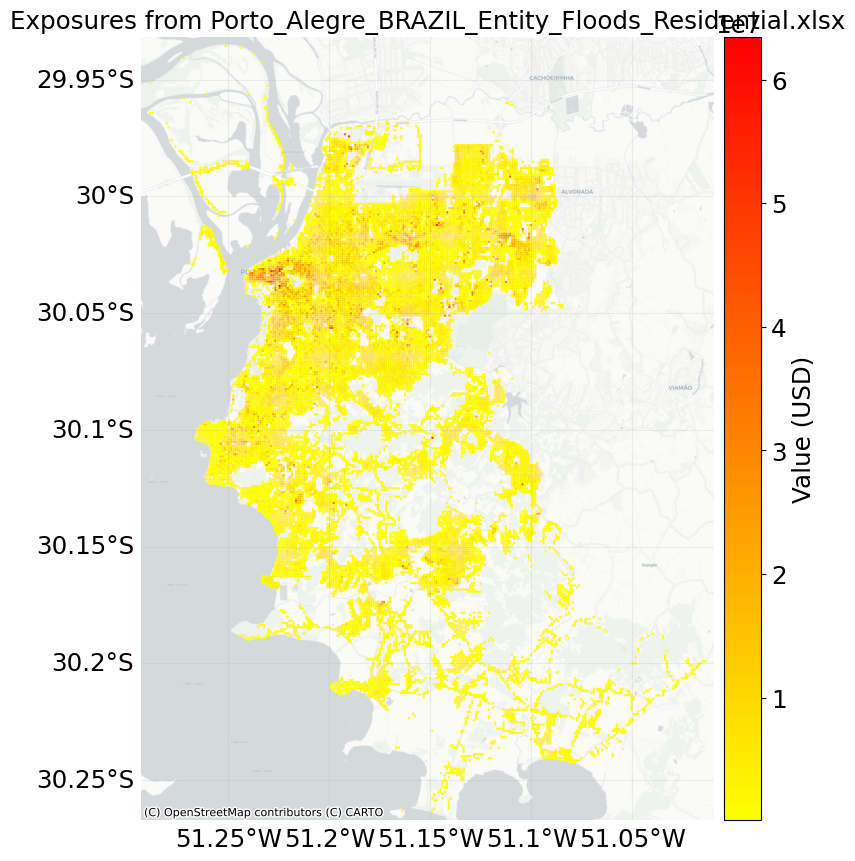

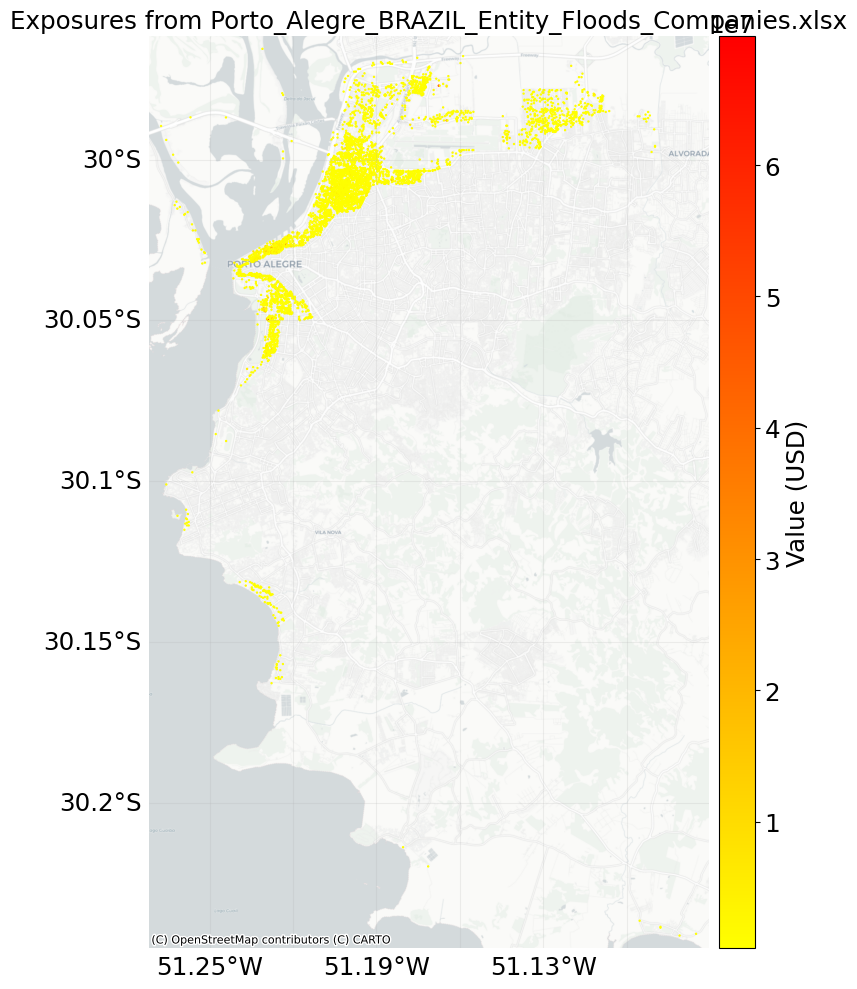

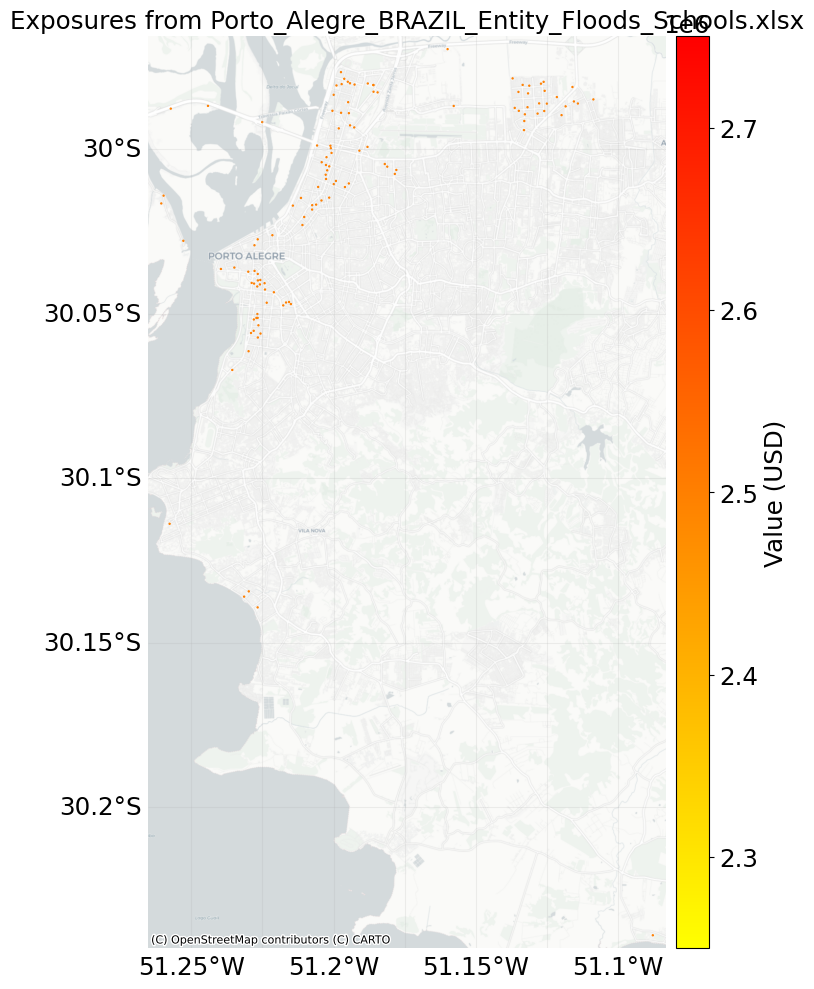

In [4]:
%matplotlib inline
import contextily as ctx

for exp in exposures_list:
    exp.plot_basemap(
        title=exp.description,   # Title for the map. This is the default value.
        ignore_zero=False,       # Whether to plot points with zero value
        buffer=500,              # Add a buffer around the points to show a larger map region (measured in meters)
        s=0.5,                   # The size of point markers on the plot
        zoom=13,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        url=ctx.providers.CartoDB.Positron,
                                 # Set a basemap using contextily – here we use CartoDB's Positron which gives a pale, monochrome basemap
                                 #     Another good option is OpenStreetMap's Mapnik (`ctx.providers.OpenStreetMap.Mapnik`)
                                 #     ... this gives a more colourful basemap
                                 #     See all options at: https://xyzservices.readthedocs.io/en/stable/gallery.html
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scale across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)          # Dimensions of the output figure
    )

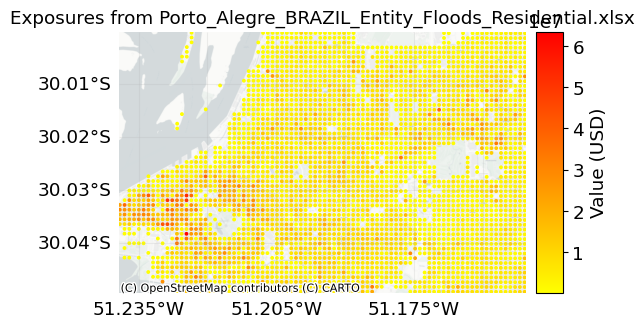

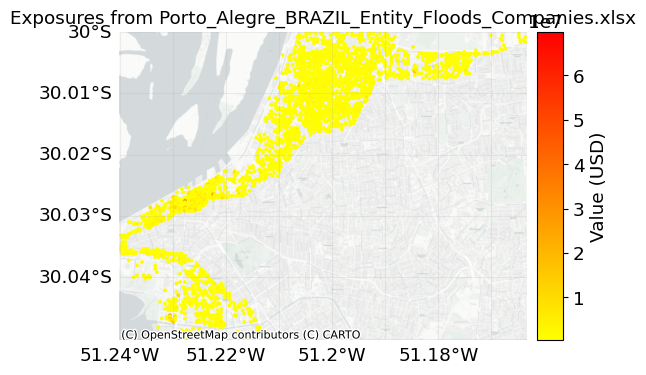

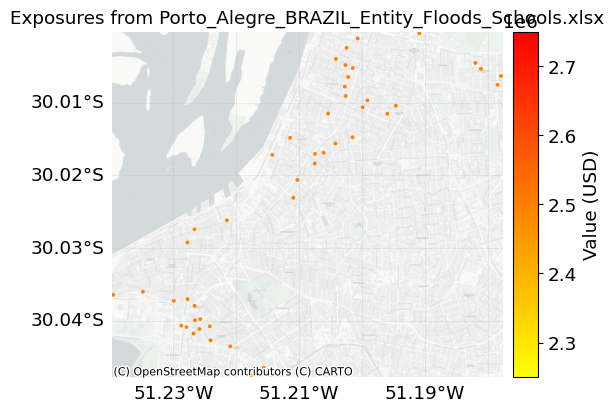

In [5]:
# Let's zoom in and plot a smaller area:

sample_region = (-51.24, -51.15, -30.05, -30.00)  # (min_lon, max_lon, min_lat, max_lat)
lon_min, lon_max, lat_min, lat_max = sample_region

for exp in exposures_list:
    exp_zoom = exp.copy(deep=True)
    exp_zoom.set_gdf(exp_zoom.gdf.cx[lon_min:lon_max, lat_min:lat_max])
    exp_zoom.plot_basemap(
        title=exp_zoom.description,   # Title for the map. This is the default value.
        ignore_zero=False,       # Whether to plot points with zero value
        buffer=30,               # Add a buffer around the points to show a larger map region (measured in meters)
        s=3,                     # The size of point markers on the plot
        zoom=16,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(6, 8)           # Dimensions of the output figure
    )

## Visualize Exposures: hexmap

When there are a lot of Exposure points, plotting them all on a map can obscure information because they overlap too much.

In this case aggregating the exposures to create a hexmap is useful. You can specify whether you'd like each hex to display the sum (most common) of the points within it, or some other function, e.g. mean or max.

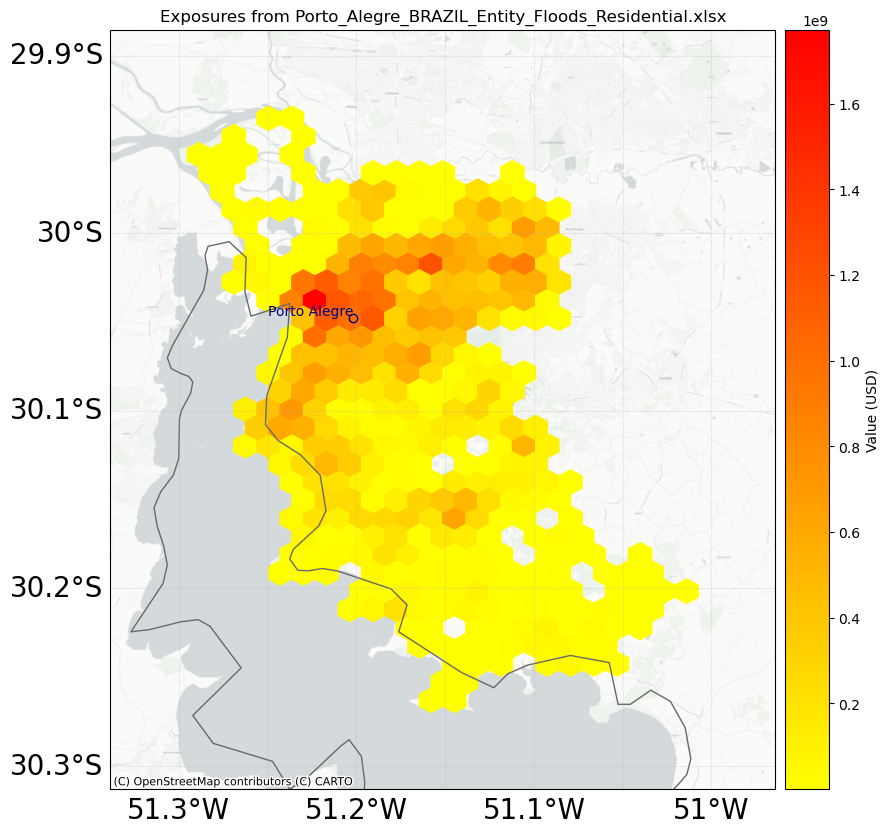

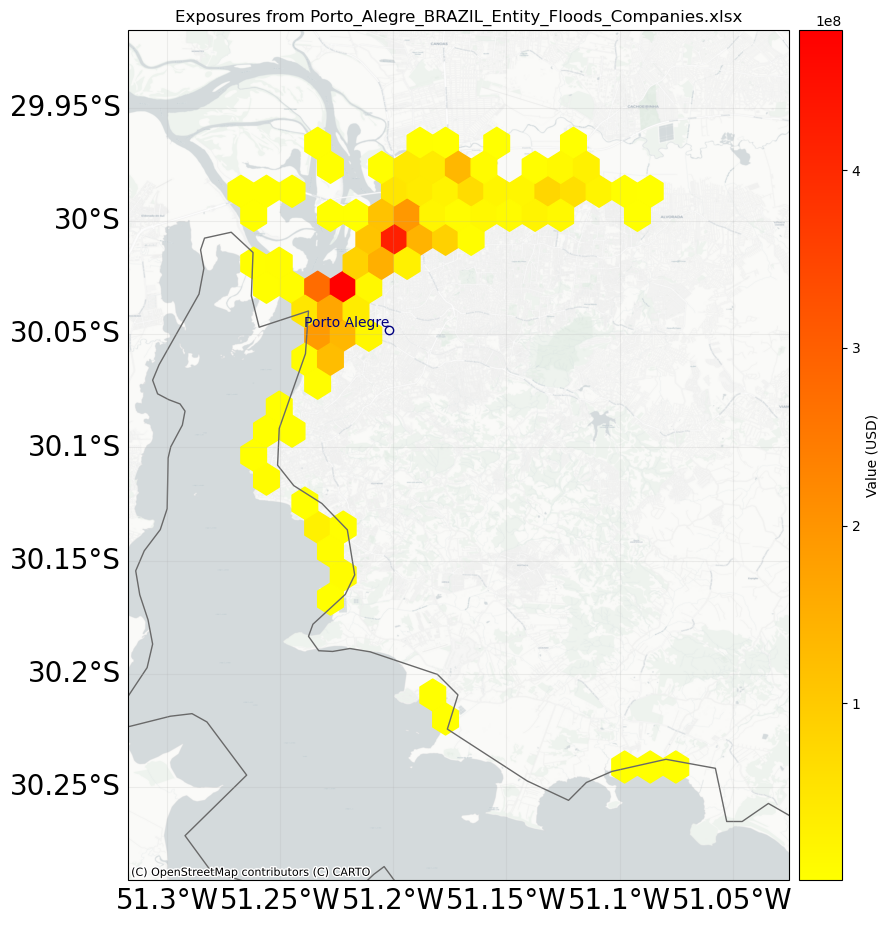

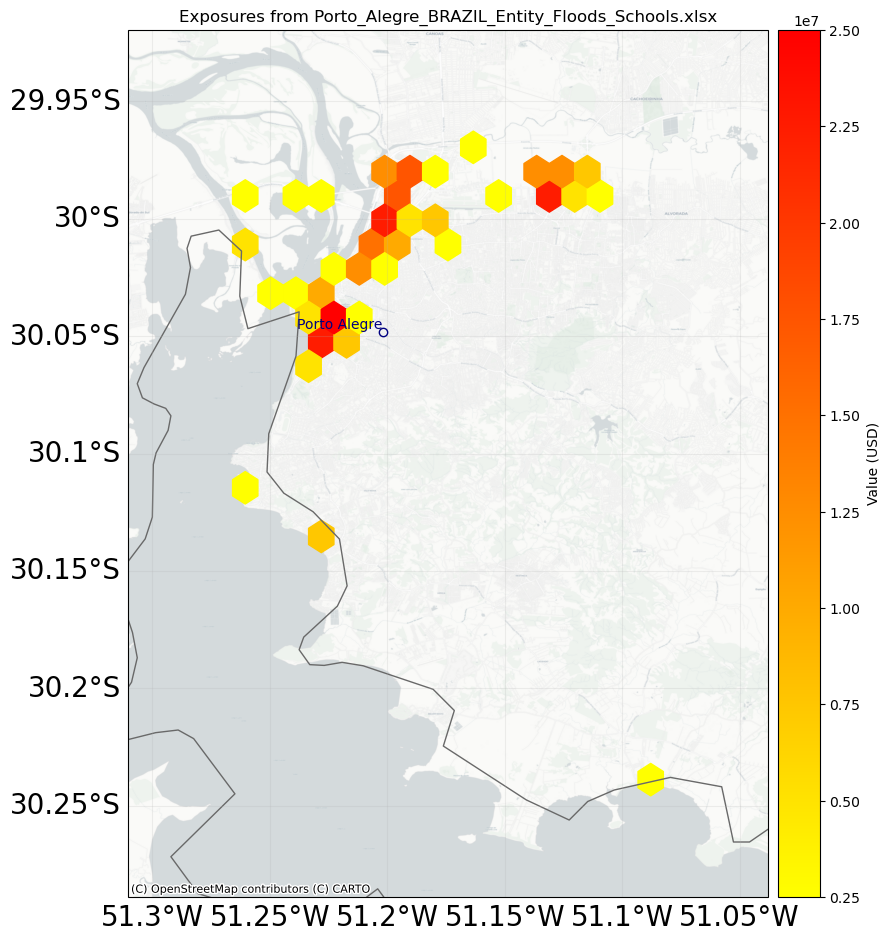

In [6]:
import numpy as np
import cartopy.crs as ccrs
from climada.util import plot as u_plot 

for exp in exposures_list:
    # (Optional) Set the number of bins in each direction of the map
    bin_size = 0.02  # The size of the hexagonal bins in units of latitude and longitude
    xmin, xmax = exp.gdf.geometry.x.min(), exp.gdf.geometry.x.max()
    ymin, ymax = exp.gdf.geometry.y.min(), exp.gdf.geometry.y.max()
    dim_x = int((xmax - xmin) / bin_size) + 8  # The binning isn't perfect, so we manually adjust this to make it look better
    dim_y = int((ymax - ymin) / bin_size)
    # Note: newer versions of CLIMADA let you use the simpler exp.latitude and exp.longitude properties

    # (Optional) standardise projections and create a basemap
    proj_plot = ccrs.PlateCarree(central_longitude=0.5 * (xmin + xmax))  # Setting a central longitude allows us to plot data that crosses the 180 degree antimeridian – not so relevant here
    _, axis, fontsize = u_plot.make_map(
        proj=proj_plot, figsize=(9, 13), adapt_fontsize=True
    )

    # Plot the hexbin
    axis = exp.plot_hexbin(
        ignore_zero=True,         # Whether to plot points with zero value
        pop_name=True,            # Add the names of populated places to the map
        buffer=0.05,              # Add a buffer around the points to show a larger map region (measured in units of latitude and longitude) (different from `plot_basemap`!)
        axis=axis,
        figsize=(8, 10),
        title=exp.description,    # Title for the map. This is the default value.
        reduce_C_function=np.sum, # How to aggregate the individual exposure points to the hexagonal bins. They are summed like this by default, but you could also use np.mean, np.median, etc.
        gridsize=(dim_x, dim_y),              # The number of hexagons to use in the x-direction across the generated map
        cmap="autumn_r",          # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
    )
    # Add a basemap – see the previous cell for details on how to customize this
    ctx.add_basemap(axis, zoom=14, source=ctx.providers.CartoDB.Positron, origin="upper", crs=proj_plot)

    